# Corsair Quant Lab · Week 01

## Goal
Build a reproducible evaluation foundation in Jupyter **and** marimo. This release runs two simple baselines on public Treasury observations; no AI model has been evaluated yet.

The shared source of calculation logic is `corsair_lab/evaluation.py`.

## Setup
Run from the project environment. The setup finds the project whether the kernel starts at the root or inside the notebooks folder.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "corsair_lab").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display, Markdown
from corsair_lab.evaluation import run_benchmark, plot_benchmark, interpretation
HORIZON = 1  # observed sessions, not calendar days

## Steps
### 1. Load the frozen data and evaluate
Sources: [DGS2](https://fred.stlouisfed.org/series/DGS2) and [DGS10](https://fred.stlouisfed.org/series/DGS10), Federal Reserve Board H.15 via FRED.

### Key assumptions
Histories start in 2020; target observations are in 2024. Values are yields in percent, errors in basis points. Missing observations are dropped per series without filling. Each origin sees only earlier/current observations. The second baseline extrapolates the trailing mean of 20 yield changes. This current snapshot is **not** historical publication-vintage data. The comparison is a development exercise, not a trading backtest or final test.

In [2]:
observations, provenance, predictions, scores = run_benchmark(HORIZON)
display(Markdown(f"Retrieved: **{provenance['retrieved_at_utc']}**. Snapshot rows: **{provenance['rows']}**. Full provenance is in `data/raw/provenance.json`."))
display(observations.head())

Retrieved: **2026-09-16T00:26:50.739858+00:00**. Snapshot rows: **1305**. Full provenance is in `data/raw/provenance.json`.

,observation_date,DGS2,DGS10
0,2020-01-01,NaN,NaN
1,2020-01-02,1.58,1.88
2,2020-01-03,1.53,1.80
3,2020-01-06,1.54,1.81
4,2020-01-07,1.54,1.83


### 2. Compare measurements
Both baselines use identical target dates and horizons. Lower absolute error means a closer numerical prediction, not necessarily a better trading strategy.

In [3]:
display(scores.round(3))

,Series,Model,Forecasts,MAE (bp),RMSE (bp)
0,DGS2,Last observed yield,250,4.552,6.153
1,DGS2,Trailing mean change,250,4.780,6.263
2,DGS10,Last observed yield,250,4.480,5.750
3,DGS10,Trailing mean change,250,4.597,5.899


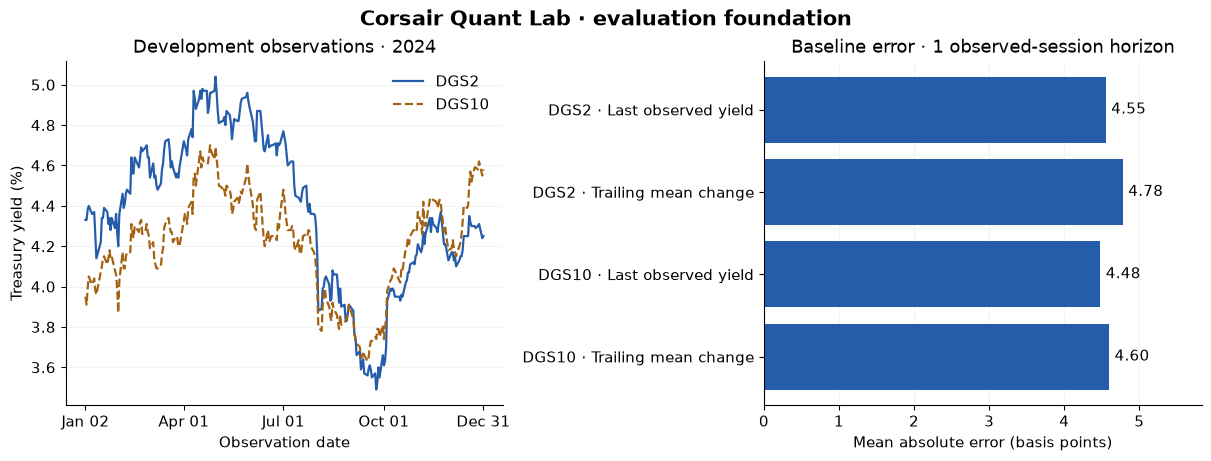

In [4]:
figure = plot_benchmark(predictions, scores)
display(figure)
import matplotlib.pyplot as plt
plt.close(figure)

## Checks
Verify chronological origins, finite predictions, and identical evaluation samples across models.

In [5]:
assert (predictions.origin_date < predictions.target_date).all()
assert predictions[["actual_pct", "prediction_pct"]].notna().all().all()
assert predictions.groupby(["series", "model"]).size().groupby(level=0).nunique().eq(1).all()
print("Chronology and sample checks passed.")

Chronology and sample checks passed.


## Takeaways

In [6]:
display(Markdown(interpretation(scores)))

**DGS10:** Last observed yield: 4.48 bp MAE; Trailing mean change: 4.60 bp MAE (250 forecasts per baseline).

**DGS2:** Last observed yield: 4.55 bp MAE; Trailing mean change: 4.78 bp MAE (250 forecasts per baseline).

These are development-period baseline measurements, not AI-model results or evidence of a profitable strategy. Differences have not been tested for statistical significance.

## Next steps
Your coding exercise: implement median absolute error, test it on a hand-calculated example, and display it in both notebooks. Week 02 adds FinBERT and one FinGPT checkpoint. Model results will remain separate from these baseline results.

Read the [roadmap](../../docs/ROADMAP.md) and [evaluation contract](../../docs/EVALUATION.md) before changing experiment assumptions.